<a href="https://colab.research.google.com/github/aditya0563/Thiranex/blob/main/Data_Cleaning_%26_Visualization_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading and Viewing the Dataset

In [3]:
df = pd.read_csv('Nike_Sales.csv')
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


Removing Duplicates

In [8]:
df.drop_duplicates(inplace=True)

Standardizing Region Names

In [9]:
region_map = {
    'bengaluru': 'Bangalore', 'Bangalore': 'Bangalore',
    'Hyd': 'Hyderabad', 'hyderbad': 'Hyderabad', 'Hyderabad': 'Hyderabad',
    'Mumbai': 'Mumbai', 'Pune': 'Pune', 'Delhi': 'Delhi', 'Kolkata': 'Kolkata'
}
df['Region'] = df['Region'].map(region_map)

Formatting Dates

In [10]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].median())

Cleaning Size and Discount Columns

In [11]:
df['Size'] = df['Size'].fillna('Unknown')

df['Discount_Applied'] = df['Discount_Applied'].fillna(0).clip(lower=0, upper=0.99)

Imputing Numerical Data (MRP & Units Sold)

In [12]:
df['MRP'] = df.groupby('Product_Line')['MRP'].transform(lambda x: x.fillna(x.median()))
df['MRP'] = df['MRP'].fillna(df['MRP'].median())

df['Units_Sold'] = df['Units_Sold'].fillna(1).apply(lambda x: max(1, round(x)))

Fixing Erroneous Revenue Values

In [13]:
def calc_revenue(row):
    if row['Revenue'] <= 0:
         return row['Units_Sold'] * row['MRP'] * (1 - row['Discount_Applied'])
    return row['Revenue']

df['Revenue'] = df.apply(calc_revenue, axis=1)

Handling Outliers in Revenue

In [14]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['Revenue'] = np.clip(df['Revenue'], a_min=None, a_max=upper_bound)

Setting Up Visualization Theme

In [15]:
sns.set_theme(style="whitegrid", palette="muted")

Plot 1: Revenue Distribution

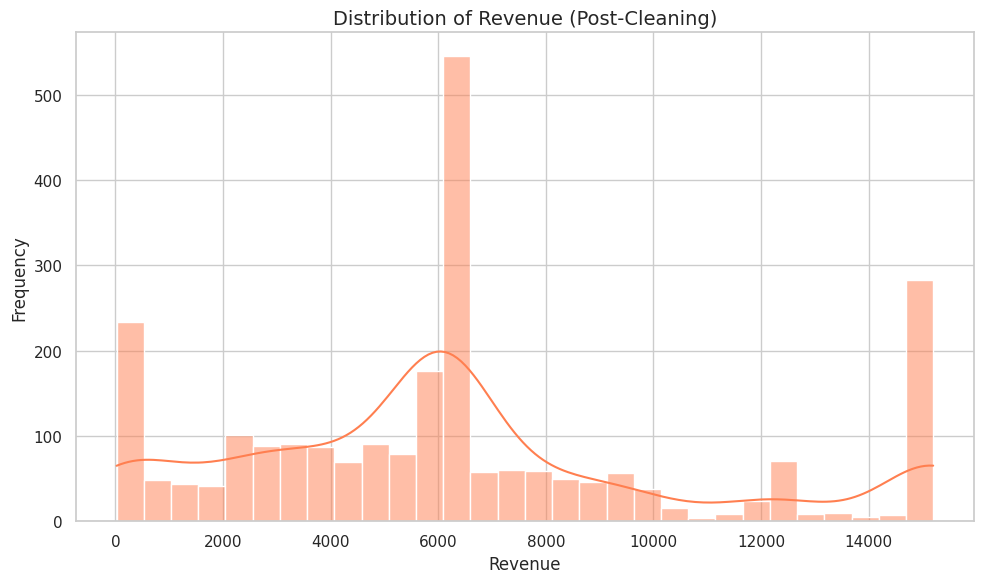

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Revenue'], kde=True, color='coral', bins=30)
plt.title('Distribution of Revenue (Post-Cleaning)', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Plot 2: Total Revenue by Region

/tmp/ipykernel_985/1330156596.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_region, x='Region', y='Revenue', palette='viridis')


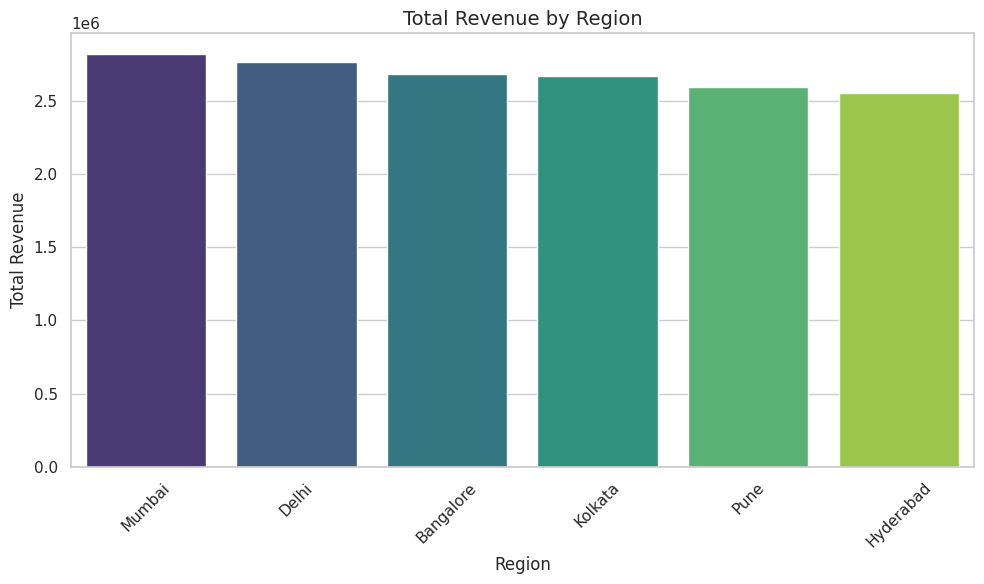

In [17]:
plt.figure(figsize=(10, 6))
revenue_by_region = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=revenue_by_region, x='Region', y='Revenue', palette='viridis')
plt.title('Total Revenue by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plot 3: Revenue vs Profit by Sales Channel

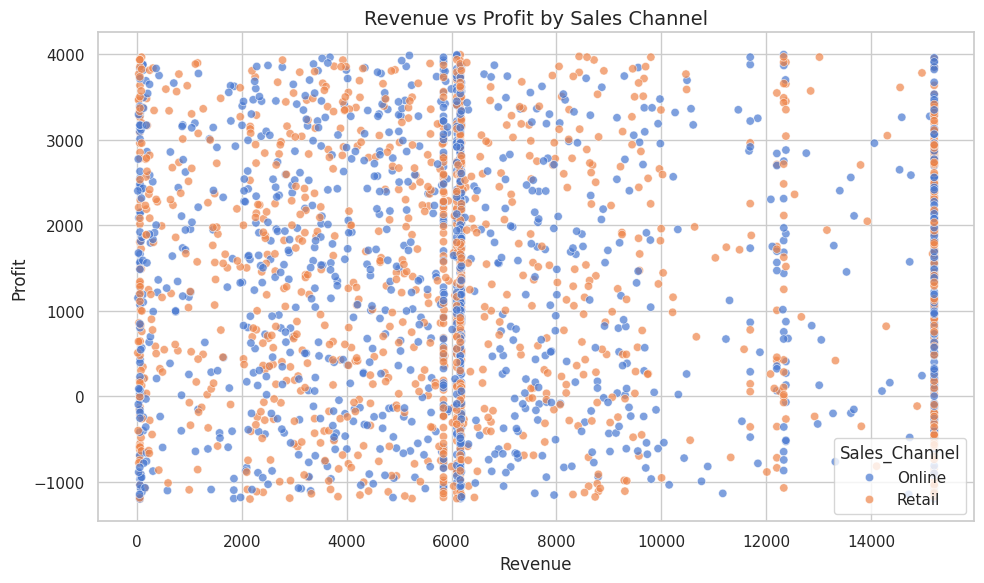

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Revenue', y='Profit', hue='Sales_Channel', alpha=0.7)
plt.title('Revenue vs Profit by Sales Channel', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

Plot 4: Correlation Matrix

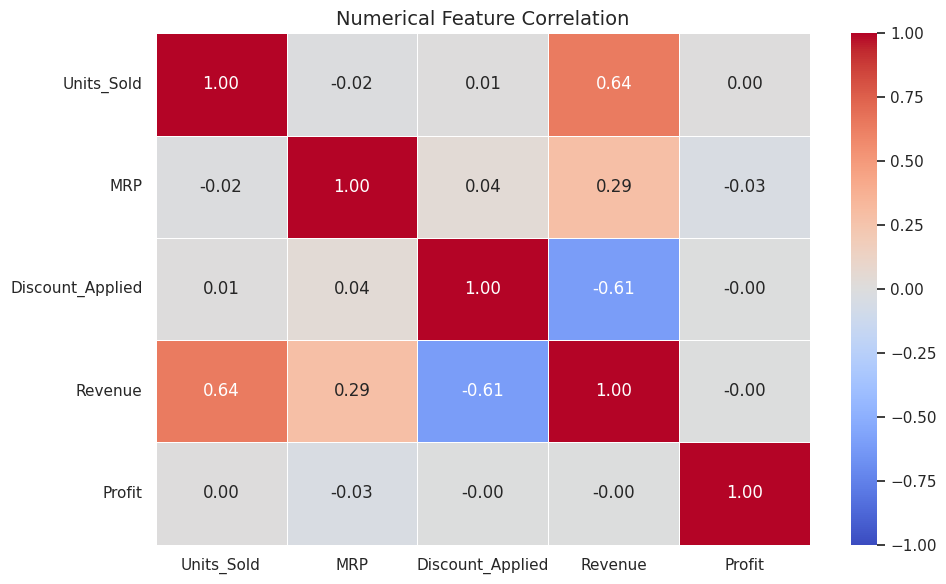

In [19]:
plt.figure(figsize=(10, 6))
num_cols = df[['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']]
corr_matrix = num_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Numerical Feature Correlation', fontsize=14)
plt.tight_layout()
plt.show()